# Воспроизведение симуляций из раздела 4

В этом ноутбуке воспроизводятся две симуляции из раздела 4 статьи *Forecast reconciliation with non-linear constraints*. Нас интересует метод NLCR: исходный прогноз $\hat y$ проецируется на множество допустимых значений, заданное нелинейным ограничением $g(y)=0$.

Далее используется OLS-вариант согласования, то есть евклидова проекция:

$$
\tilde y = \arg\min_z \|z - \hat y\|^2 \quad \text{при условии } g(z)=0.
$$

Качество сравнивается по расстоянию до истинного значения: считаем долю случаев, когда $\|\tilde y-y\| < \|\hat y-y\|$.


In [1]:
import math
import os
import random
import warnings
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import minimize, minimize_scalar

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
SIMULATION_DIR = Path.cwd() if Path.cwd().name == "simulations" else Path.cwd() / "simulations"

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120


## Общие функции

Тут мы определяем функции, которые понадобятся нам в дальнейших экспериментах:
- генерация истинных значений;
- построение базовых прогнозов;
- проекция на ограничение;
- построение графиков;

In [2]:
def quartic_true(y2):
    return np.array([y2**4, y2], dtype=float)


def quartic_curvature(y2):
    return 12.0 * y2**2 / (1.0 + 16.0 * y2**6) ** 2


def quartic_normal(y2):
    grad = np.array([1.0, -4.0 * y2**3], dtype=float)
    return grad / np.linalg.norm(grad)


def quartic_base_mean(y2, beta):
    return quartic_true(y2) + beta * quartic_normal(y2)


def reconcile_quartic(y_hat):
    y1_hat, y2_hat = y_hat

    def objective(x):
        return (x**4 - y1_hat) ** 2 + (x - y2_hat) ** 2

    result = minimize_scalar(objective, bounds=(-3.0, 3.0), method="bounded")
    y2_reconciled = result.x
    return np.array([y2_reconciled**4, y2_reconciled])


def run_simulation_1(y2_grid, betas, n_mc=1000, seed=123):
    rng = np.random.default_rng(seed)
    cov = np.diag([0.1, 0.1])
    rows = []
    base_generation_seconds = 0.0
    reconciliation_seconds = 0.0

    for beta in betas:
        for y2 in y2_grid:
            y_true = quartic_true(y2)
            mean = quartic_base_mean(y2, beta)
            base_started = perf_counter()
            draws = rng.multivariate_normal(mean, cov, size=n_mc)
            base_generation_seconds += perf_counter() - base_started

            improved = 0
            reconciliation_started = perf_counter()
            for y_hat in draws:
                y_rec = reconcile_quartic(y_hat)
                improved += np.linalg.norm(y_rec - y_true) < np.linalg.norm(y_hat - y_true)
            reconciliation_seconds += perf_counter() - reconciliation_started

            rows.append({
                "beta": beta,
                "y2": y2,
                "curvature": quartic_curvature(y2),
                "n_mc": n_mc,
                "n_valid": n_mc,
                "n_fail": 0,
                "p_reconciled_better": improved / n_mc,
            })

    results = pd.DataFrame(rows).sort_values(["beta", "curvature", "y2"]).reset_index(drop=True)
    timing = {
        "experiment": "Simulation 1: quartic",
        "n_forecasts": len(y2_grid) * len(betas) * n_mc,
        "baseline_prediction_seconds": base_generation_seconds,
        "reconciliation_seconds": reconciliation_seconds,
        "total_prediction_seconds": base_generation_seconds + reconciliation_seconds,
    }
    return results, timing


def plot_simulation_1(results):
    fig, ax = plt.subplots(figsize=(10, 6))

    for beta, group in results.groupby("beta"):
        group = group.sort_values("curvature")
        x = group["curvature"].to_numpy()
        y = 100 * group["p_reconciled_better"].to_numpy()
        ax.scatter(x, y, s=14, alpha=0.55, label=f"beta={beta:g}")

        if len(group) > 10:
            from statsmodels.nonparametric.smoothers_lowess import lowess
            smooth = lowess(y, x, frac=0.2, return_sorted=True)
            ax.plot(smooth[:, 0], smooth[:, 1], linewidth=1.6)

    ax.set_title("Simulation 1: quartic constraint")
    ax.set_xlabel(r"curvature $\kappa$ of $y_1=y_2^4$")
    ax.set_ylabel(r"% of cases where $d(\hat y,y)>d(\tilde y,y)$")
    ax.grid(alpha=0.25)
    ax.legend(ncol=2, fontsize=9)
    return fig, ax


In [3]:
def ratio_constraint_projection(y_hat):
    y1_hat, y2_hat, y3_hat = y_hat

    def best_y2(y3):
        return (100.0 * y1_hat / y3 + y2_hat) / (1.0 + 10000.0 / y3**2)

    def objective(y3):
        y2 = best_y2(y3)
        y1 = 100.0 * y2 / y3
        return (y1 - y1_hat) ** 2 + (y2 - y2_hat) ** 2 + (y3 - y3_hat) ** 2

    result = minimize_scalar(objective, bounds=(1e-8, 2000.0), method="bounded")
    y3_rec = result.x
    y2_rec = best_y2(y3_rec)
    return np.array([100.0 * y2_rec / y3_rec, y2_rec, y3_rec])


def covariance_matrix(var1, var2, rho):
    cov12 = rho * math.sqrt(var1 * var2)
    return np.array([[var1, cov12], [cov12, var2]])


def ratio_delta(m, alpha):
    if np.isclose(m, 0.0):
        return np.array([alpha, 0.0])
    tangent = math.tan(m)
    return alpha * np.array([1.0, tangent]) / math.sqrt(1.0 + tangent**2)


def draw_ratio_truths(rho, n_true, rng):
    mu = np.array([100.0, 300.0])
    cov = covariance_matrix(5.0, 10.0, rho)
    y23 = rng.multivariate_normal(mu, cov, size=n_true)
    y1 = 100.0 * y23[:, 0] / y23[:, 1]
    return np.column_stack([y1, y23])


def draw_ratio_forecast(rho, gamma, m, alpha, beta, rng):
    mu = np.array([100.0, 300.0]) + ratio_delta(m, alpha)
    cov = gamma * covariance_matrix(5.0, 10.0, rho)
    y2_hat, y3_hat = rng.multivariate_normal(mu, cov)
    eps = rng.normal(beta, 10.0)
    y1_hat = 100.0 * y2_hat / y3_hat + eps
    return np.array([y1_hat, y2_hat, y3_hat])


def run_simulation_2(rhos, gammas, ms, alphas, betas, n_true=1000, seed=123):
    master_rng = np.random.default_rng(seed)
    truths = {}
    rows = []
    base_generation_seconds = 0.0
    reconciliation_seconds = 0.0

    for rho in rhos:
        rng = np.random.default_rng(master_rng.integers(0, 2**32 - 1))
        truths[rho] = draw_ratio_truths(rho, n_true, rng)

    for rho in rhos:
        for gamma in gammas:
            for m in ms:
                for alpha in alphas:
                    for beta in betas:
                        rng = np.random.default_rng(master_rng.integers(0, 2**32 - 1))
                        base_started = perf_counter()
                        forecasts = np.array([
                            draw_ratio_forecast(rho, gamma, m, alpha, beta, rng)
                            for _ in range(n_true)
                        ])
                        base_generation_seconds += perf_counter() - base_started

                        improved = 0
                        reconciliation_started = perf_counter()
                        for y_true, y_hat in zip(truths[rho], forecasts):
                            y_rec = ratio_constraint_projection(y_hat)
                            improved += np.linalg.norm(y_rec - y_true) < np.linalg.norm(y_hat - y_true)
                        reconciliation_seconds += perf_counter() - reconciliation_started

                        rows.append({
                            "rho": rho,
                            "gamma": gamma,
                            "m": m,
                            "alpha": alpha,
                            "beta": beta,
                            "n_true": n_true,
                            "n_valid": n_true,
                            "n_fail": 0,
                            "p_reconciled_better": improved / n_true,
                        })

    results = pd.DataFrame(rows).sort_values(["gamma", "m", "rho", "alpha", "beta"]).reset_index(drop=True)
    timing = {
        "experiment": "Simulation 2: ratio",
        "n_forecasts": len(rhos) * len(gammas) * len(ms) * len(alphas) * len(betas) * n_true,
        "baseline_prediction_seconds": base_generation_seconds,
        "reconciliation_seconds": reconciliation_seconds,
        "total_prediction_seconds": base_generation_seconds + reconciliation_seconds,
    }
    return results, timing


def plot_simulation_2(results, gamma=1.0):
    rhos = sorted(results["rho"].unique())
    ms = sorted(results["m"].unique())
    alphas = sorted(results["alpha"].unique())
    betas = sorted(results["beta"].unique())

    fig, axes = plt.subplots(len(ms), len(rhos), figsize=(16, 8), constrained_layout=True, sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(len(ms), len(rhos))

    for i, m in enumerate(ms):
        for j, rho in enumerate(rhos):
            ax = axes[i, j]
            part = results[
                np.isclose(results["gamma"], gamma)
                & np.isclose(results["m"], m)
                & np.isclose(results["rho"], rho)
            ]
            table = part.pivot(index="alpha", columns="beta", values="p_reconciled_better").reindex(index=alphas, columns=betas)
            image = ax.imshow(100 * table.to_numpy(), origin="lower", aspect="auto", vmin=80, vmax=100)

            for row, alpha in enumerate(alphas):
                for col, beta in enumerate(betas):
                    ax.text(col, row, f"{100 * table.loc[alpha, beta]:.1f}", ha="center", va="center", fontsize=7)

            ax.set_title(f"rho={rho:g}, m={m:.3f}")
            ax.set_xticks(range(len(betas)), [f"{b:g}" for b in betas])
            ax.set_yticks(range(len(alphas)), [f"{a:g}" for a in alphas])
            if i == len(ms) - 1:
                ax.set_xlabel("beta")
            if j == 0:
                ax.set_ylabel("alpha")

    fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.9, label="% of successful reconciliations")
    return fig, axes


## Эксперимент 1: квартическое ограничение

В первой симуляции допустимые значения лежат на кривой $y_1=y_2^4$. Базовый прогноз строится как случайное отклонение от истинной точки, причем среднее смещается вдоль нормали к кривой. Параметр $\beta$ отвечает за направление и величину этого смещения.


In [4]:
y2_grid = np.round(np.arange(-1.5, 1.5 + 0.01, 0.01), 2)
betas_1 = (-0.3, 0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3)

res1, timing1 = run_simulation_1(y2_grid, betas_1, n_mc=1000, seed=SEED)
res1.to_csv(SIMULATION_DIR / "simulation1_results.csv", index=False)

display(res1.head())
print(res1.shape)


,beta,y2,curvature,n_mc,n_valid,n_fail,p_reconciled_better
0,-0.3,0.00,0.000000,1000,1000,0,0.961
1,-0.3,-1.50,0.000804,1000,1000,0,1.000
2,-0.3,1.50,0.000804,1000,1000,0,0.998
3,-0.3,-1.49,0.000859,1000,1000,0,1.000
4,-0.3,1.49,0.000859,1000,1000,0,0.997


(2408, 7)


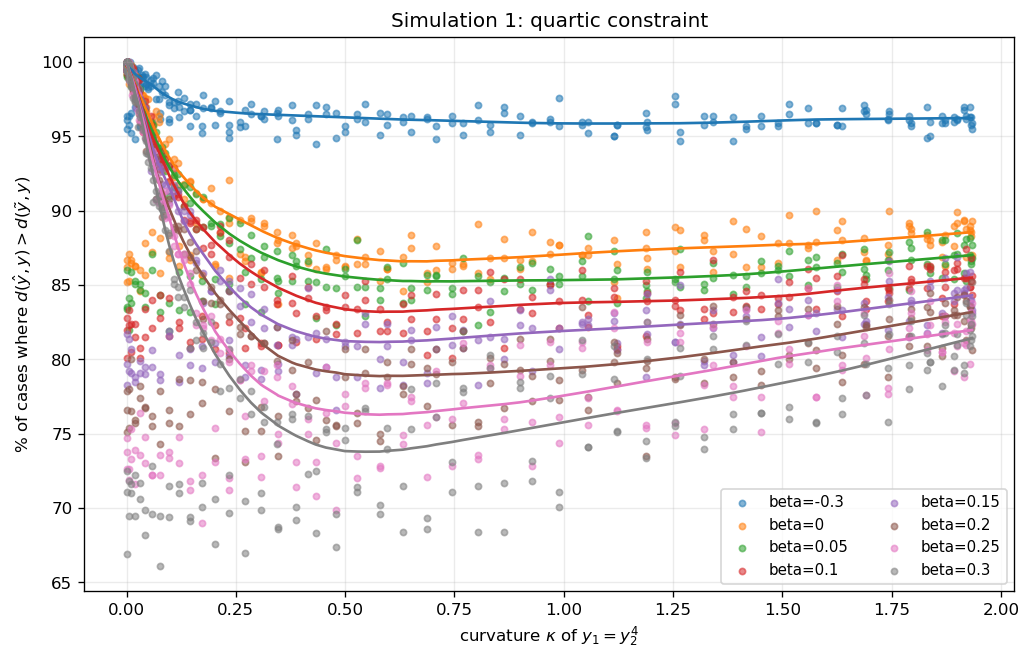

In [5]:
fig1, ax1 = plot_simulation_1(res1)
fig1.savefig(SIMULATION_DIR / "simulation1_output.png", dpi=200, bbox_inches="tight")
plt.show()


В этом эксперименте удобно смотреть не на саму координату $y_2$, а на кривизну ограничения. Если проекция часто улучшает прогноз, значение на графике находится выше 50%.


## Эксперимент 2: ограничение-отношение

Во второй симуляции используется ограничение $y_1=100y_2/y_3$. Оно уже не является выпуклым, поэтому это более сложный случай для NLCR. В эксперименте меняются корреляция $\rho$, масштаб дисперсии $\gamma$, направление сдвига $m$ и параметры смещения $\alpha, \beta$.


In [6]:
rhos = (-0.8, -0.4, 0.0, 0.4, 0.8)
gammas = (0.5, 1.0, 1.5)
ms = (-math.pi / 4, 0.0, math.pi / 4)
alphas = (-50.0, -25.0, 0.0, 25.0, 50.0)
betas_2 = (-25.0, -10.0, 0.0, 10.0, 25.0)

res2, timing2 = run_simulation_2(rhos, gammas, ms, alphas, betas_2, n_true=1000, seed=SEED)
res2.to_csv(SIMULATION_DIR / "simulation2_results.csv", index=False)

display(res2.head())
print(res2.shape)


,rho,gamma,m,alpha,beta,n_true,n_valid,n_fail,p_reconciled_better
0,-0.8,0.5,-0.785398,-50.0,-25.0,1000,1000,0,0.997
1,-0.8,0.5,-0.785398,-50.0,-10.0,1000,1000,0,0.941
2,-0.8,0.5,-0.785398,-50.0,0.0,1000,1000,0,0.866
3,-0.8,0.5,-0.785398,-50.0,10.0,1000,1000,0,0.932
4,-0.8,0.5,-0.785398,-50.0,25.0,1000,1000,0,0.997


(1125, 9)


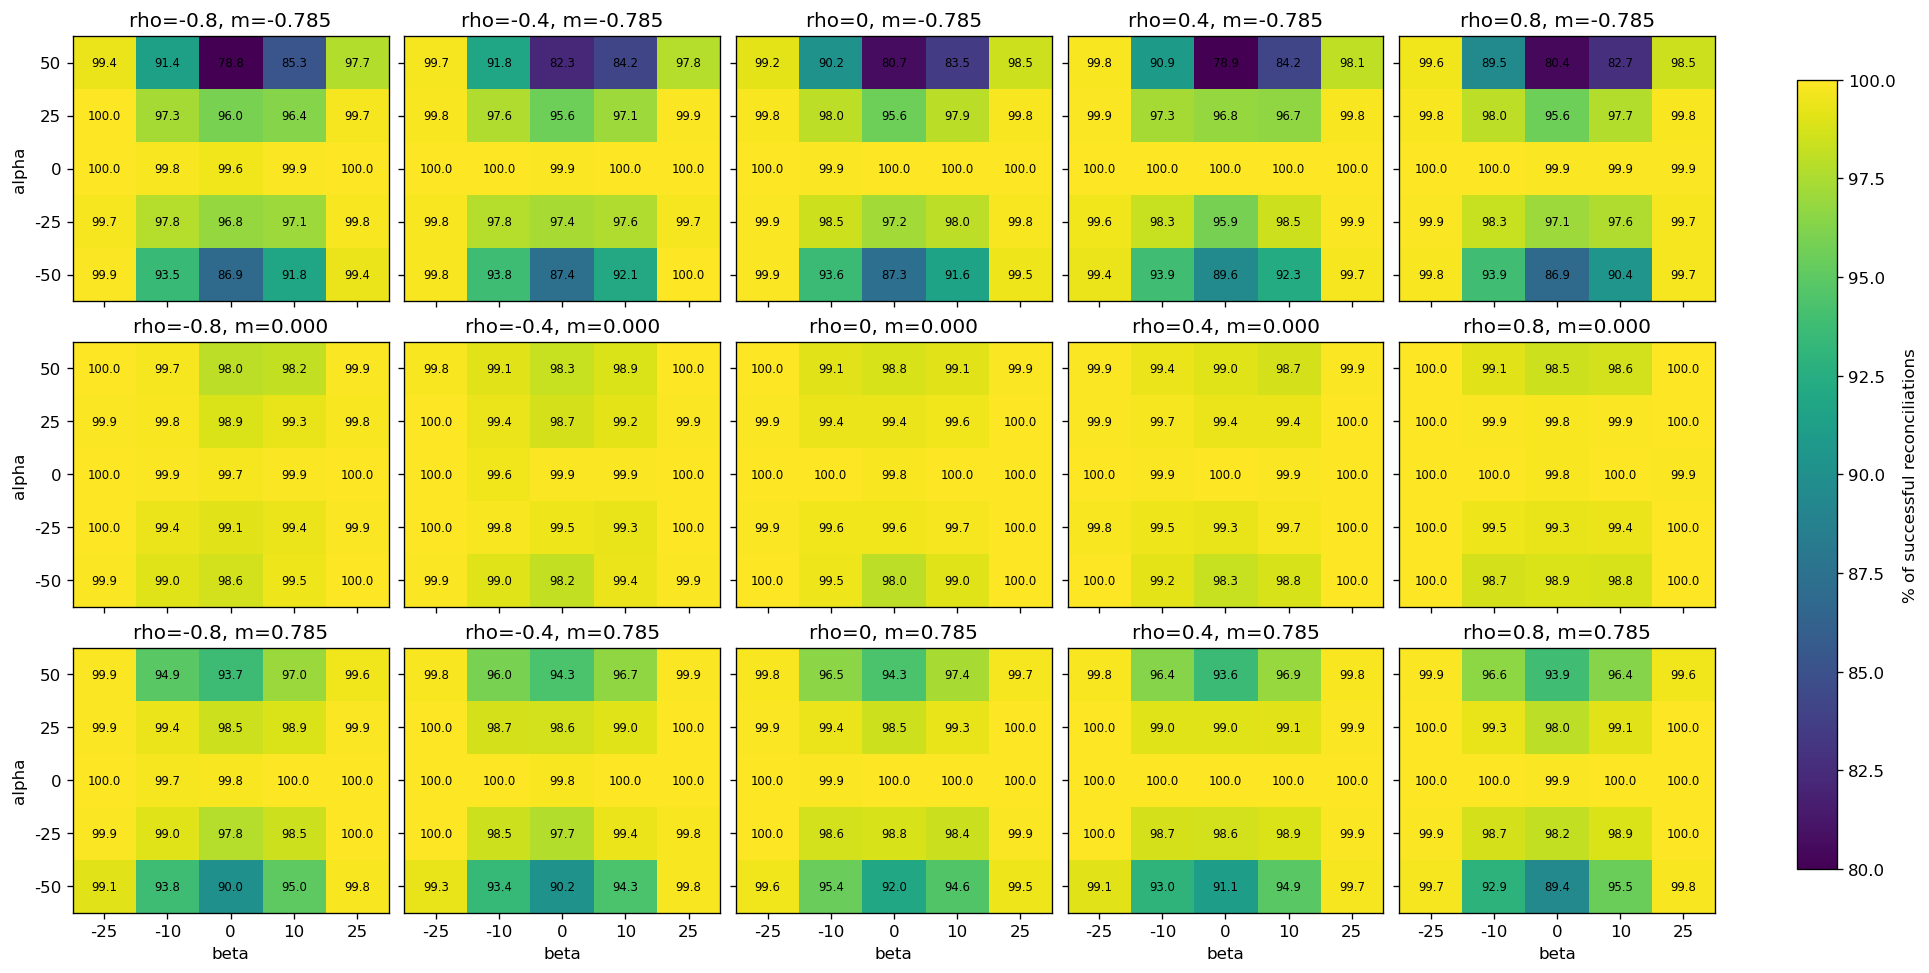

In [7]:
fig2, axes2 = plot_simulation_2(res2, gamma=1.0)
fig2.savefig(SIMULATION_DIR / "simulation2_output.png", dpi=200, bbox_inches="tight")
plt.show()


timing_results = pd.DataFrame([timing1, timing2])
timing_results["overhead_seconds"] = timing_results["reconciliation_seconds"]
timing_results["slowdown_vs_base"] = (
    timing_results["total_prediction_seconds"] / timing_results["baseline_prediction_seconds"]
)
timing_results["baseline_ms_per_forecast"] = (
    1000.0 * timing_results["baseline_prediction_seconds"] / timing_results["n_forecasts"]
)
timing_results["reconciliation_ms_per_forecast"] = (
    1000.0 * timing_results["reconciliation_seconds"] / timing_results["n_forecasts"]
)
timing_results["total_ms_per_forecast"] = (
    1000.0 * timing_results["total_prediction_seconds"] / timing_results["n_forecasts"]
)
timing_results.to_csv(SIMULATION_DIR / "simulation_timing.csv", index=False)


## Время выполнения

В симуляциях отдельно измеряется генерация базовых прогнозов и время проекции на нелинейное ограничение. Таблица нормирует результаты на один Monte Carlo forecast.

,experiment,n_forecasts,"baseline, ms/forecast","projection, ms/forecast","total, ms/forecast",slowdown vs baseline
0,Simulation 1: quartic,2408000,0.0002,0.0971,0.0973,545.0x
1,Simulation 2: ratio,1125000,0.1108,0.0835,0.1943,1.8x


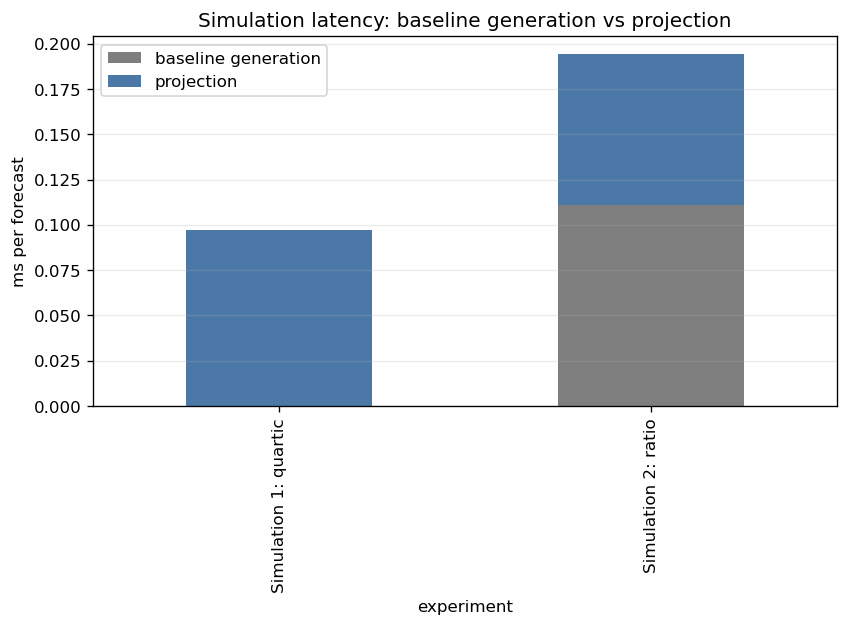

In [8]:
timing_view = timing_results.copy()
timing_view = timing_view[[
    "experiment", "n_forecasts", "baseline_ms_per_forecast",
    "reconciliation_ms_per_forecast", "total_ms_per_forecast", "slowdown_vs_base",
]].rename(columns={
    "baseline_ms_per_forecast": "baseline, ms/forecast",
    "reconciliation_ms_per_forecast": "projection, ms/forecast",
    "total_ms_per_forecast": "total, ms/forecast",
    "slowdown_vs_base": "slowdown vs baseline",
})

display(
    timing_view.style.format({
        "baseline, ms/forecast": "{:.4f}",
        "projection, ms/forecast": "{:.4f}",
        "total, ms/forecast": "{:.4f}",
        "slowdown vs baseline": "{:.1f}x",
    })
)

plot_data = timing_results.set_index("experiment")[["baseline_ms_per_forecast", "reconciliation_ms_per_forecast"]]
fig, ax = plt.subplots(figsize=(8, 4))
plot_data.plot(kind="bar", stacked=True, ax=ax, color=["#7E7E7E", "#4C78A8"])
ax.set_ylabel("ms per forecast")
ax.set_title("Simulation latency: baseline generation vs projection")
ax.grid(axis="y", alpha=0.25)
ax.legend(["baseline generation", "projection"])
fig.savefig(SIMULATION_DIR / "simulation_timing.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)


## Выводы

- В первой симуляции NLCR улучшил прогноз во всех рассмотренных точках сетки чаще, чем в 50% случаев. Средняя доля улучшений равна примерно 89.6%, минимум по сетке равен 66.1%, максимум достигает 100%. Это означает, что для ограничения $y_1=y_2^4$ проекция в целом работает устойчиво, хотя эффект зависит от положения на кривой и параметра смещения $\beta$.

- Во второй симуляции результат оказался еще сильнее: средняя доля улучшений равна примерно 98.1%, медиана равна 99.6%, а минимум по всей сетке параметров составляет 78.8%. Для невыпуклого ограничения $y_1=100y_2/y_3$ это хороший результат, потому что метод почти всегда возвращает прогноз ближе к истинному значению.

- Полученные результаты качественно похожи на результаты раздела 4 статьи. В обоих экспериментах воспроизводится основной вывод авторов: если нелинейное ограничение действительно описывает структуру данных, то NLCR часто улучшает базовые прогнозы. Небольшие отличия в отдельных числах естественны из-за численной реализации проекции, случайного моделирования и расширенной сетки значений $m$ во втором эксперименте.

- В первой симуляции генерация baseline занимает `0.00018` мс на прогноз, а проекция — `0.0971` мс, увеличивая полное время примерно в `545.0x`. Во второй симуляции baseline занимает `0.1108` мс, проекция — `0.0835` мс, а полное замедление составляет `1.75x`. Разница связана с тем, что генерация ratio-прогноза сама включает цикл случайного моделирования.